# Usage example

This notebook intends to show a possible example usage when one needs to compare observations and model predictions e.g. deriving age and metallicity from grid models. We took some random SDSS spectra from red galaxies. They have both measured velocity dispersion and redshifts. Using this information we can de-redshift and broaden to a common resolution and measure the indices in the observed spectra. Also, because they have an associated error spectrum, we can estimate the errors in hte index measurements by simulating different spectra.

In [1]:
from pacce_wapper import pacce
import numpy as np

In [2]:
sdss_spectra = pacce(filename='./sdss_table_example.dat', path_to_files='./sdss_example/',
         IndexDefs='./suport_files/less_defs.ind', sigma_fin=300, compute_idx='compute.txt',
         print_log='sdss_log.txt', simulate=100, path_plots='./sdss_example/plots/')

In [307]:
sdss_spectra['e_MgFe_prime'] = np.sqrt(
    (sdss_spectra['MgFe_prime']*sdss_spectra['e_Mgb']/sdss_spectra['Mgb'])**2 + 
    ((sdss_spectra['Mgb']/sdss_spectra['MgFe_prime'])**2)*((0.72*sdss_spectra['e_Fe5270'])**2+(0.28*sdss_spectra['e_Fe5335'])**2)

)/2.0

We also asked the code to save images containing the measurments of the indices in a folder.

Now, we can measure the same indices in the models. in order to compare them. Because they dont have an error spectrum, we do not compute new spectra. We broaden the spectra to 300 km/s, matching the broadening stablished for the data.

In [272]:
miles_models = pacce(filename='./miles_table.dat', path_to_files='./sdss_example/models/',
         IndexDefs='./suport_files/less_defs.ind', FWHM_ini=2.51, sigma_fin=300,
         compute_idx='compute.txt', print_log='models_log.txt')



The pandas functionalities make it easier to slice, build the grid, derive parameters and plot the data. 

In [308]:
data_points = sdss_spectra[['MgFe_prime','Hbeta_o']]
e_data_points = sdss_spectra[['e_MgFe_prime','e_Hbeta_o']]

In [309]:
from scipy.interpolate import LinearNDInterpolator

In [310]:
x = miles_models['Mgb']
y = miles_models['Hbeta_o']
age = miles_models['age']
met = miles_models['met']

age_interp = LinearNDInterpolator(list(zip(x, y)), age)
met_interp = LinearNDInterpolator(list(zip(x, y)), met)

sdss_spectra['age'] = age_interp(data_points)
sdss_spectra['met'] = met_interp(data_points)

Now we already have the derived ages and metalicities for the galaxies in our sample.
In order to plot the data it is even easier!

In [311]:
grid = miles_models.pivot(columns='age', index='met', values=['Hbeta_o', 'MgFe_prime'])

age_to_plot = [0.5,1.0,3.0,5.0,14.0]
met_to_plot = [-1.49, -0.66, 0.06, 0.40]

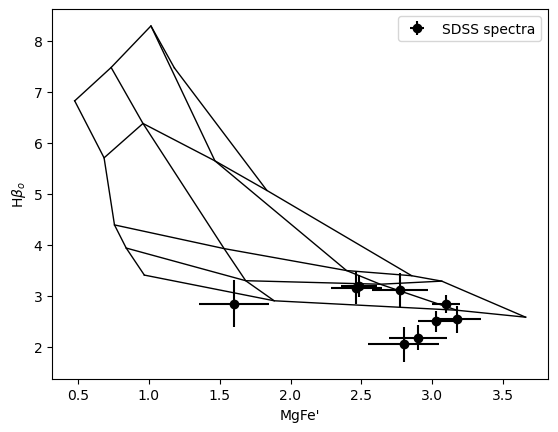

In [317]:
plt.plot(grid['MgFe_prime'][age_to_plot].loc[met_to_plot],
         grid['Hbeta_o'][age_to_plot].loc[met_to_plot], 'k-', lw=1)
plt.plot(grid['MgFe_prime'][age_to_plot].loc[met_to_plot].T,
         grid['Hbeta_o'][age_to_plot].loc[met_to_plot].T, 'k-', lw=1)
plt.errorbar(data_points['MgFe_prime'], data_points['Hbeta_o'],
              xerr=e_data_points['e_MgFe_prime'], yerr=e_data_points['e_Hbeta_o'], 
              fmt="ok", label="SDSS spectra")

plt.legend()

plt.xlabel(r"MgFe'")

plt.ylabel(r'H$\beta_o$')

plt.show()


Now comes the fun part! try using your own data and matching with the models. Are the points affected by dust? Ionized gas? Models need extention?
Hope this tutorial was helpful and good luck interpreting your data.